# Testing Data Retrieval and Database Building from WQP
Using WQP's webservice APIs

Good density, sometimes very dense other times medium sparse.

In [1]:
# %pip -q install pandas

In [2]:
import requests
import pandas as pd
from io import StringIO

url = "https://www.waterqualitydata.us/data/Result/search"
# bbox = "-88.7,41.3,-84.4,46.4"  # lake michigan rough bounding box
# bbox = "-82.36,27.84,-82.25,27.89"  # riverview, FL (alafia river)
# bbox = "-95.55,29.73,-95.28,29.78"  # houston, TX
# bbox = "-87.75,41.86,-87.58,41.95"
bbox = "-90.35,38.55,-90.05,38.75"

params = [
    # ("countrycode", "LE"),
    ("bBox", bbox),
    ("dataProfile", "resultPhysChem"),
    ("providers", "NWIS"),
    ("providers", "STORET"),
    ("mimeType", "csv"),
    ("zip", "no"),
    ("startDateLo", "01-01-2010"),
    ("startDateHi", "12-31-2020"),
]

r = requests.get(url, params=params, timeout=180)
print("STATUS:", r.status_code)
print("URL:", r.url)
print("Warning:", r.headers.get("Warning"))
print("BODY preview:", r.text[:300])

r.raise_for_status()
df = pd.read_csv(StringIO(r.text))
df.head()


STATUS: 200
URL: https://www.waterqualitydata.us/data/Result/search?bBox=-90.35%2C38.55%2C-90.05%2C38.75&dataProfile=resultPhysChem&providers=NWIS&providers=STORET&mimeType=csv&zip=no&startDateLo=01-01-2010&startDateHi=12-31-2020
BODY preview: OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,ActivityEndTime/Time,ActivityEndTime/TimeZoneCode,ActivityRelativeDepthName,Activit


C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2631006031.py:31: DtypeWarning: Columns (5,9,10,11,25,27,28,41,45,47,50,61,62,73,76) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(StringIO(r.text))


,OrganizationIdentifier,OrganizationFormalName,ActivityIdentifier,ActivityTypeCode,ActivityMediaName,ActivityMediaSubdivisionName,ActivityStartDate,ActivityStartTime/Time,ActivityStartTime/TimeZoneCode,ActivityEndDate,...,LaboratoryName,AnalysisStartDate,ResultLaboratoryCommentText,ResultDetectionQuantitationLimitUrl,DetectionQuantitationLimitTypeName,DetectionQuantitationLimitMeasure/MeasureValue,DetectionQuantitationLimitMeasure/MeasureUnitCode,LabSamplePreparationUrl,LastUpdated,ProviderName
0,SLU_WQX,St. Louis University,SLU_WQX-Jennings 2 2017-02-25_10 logF,Field Msr/Obs-Portable Data Logger,Water,NaN,2017-02-25,10:00:00,CST,NaN,...,NaN,2017-02-25,NaN,NaN,NaN,NaN,NaN,NaN,2018-09-09T16:30:41,STORET
1,SLU_WQX,St. Louis University,SLU_WQX-Ferguson 1 2017-12-08_04 logF,Field Msr/Obs-Portable Data Logger,Water,NaN,2017-12-08,04:00:00,CST,NaN,...,NaN,2017-12-08,NaN,NaN,NaN,NaN,NaN,NaN,2018-09-09T16:27:10,STORET
2,SLU_WQX,St. Louis University,SLU_WQX-Jennings 2 2017-02-19_00 logC,Field Msr/Obs-Portable Data Logger,Water,NaN,2017-02-19,00:00:00,CST,NaN,...,NaN,2017-02-19,NaN,https://www.waterqualitydata.us/data/providers...,Practical Quantitation Limit,"0 - 15,000",uS/cm,NaN,2018-09-09T14:45:33,STORET
3,SLU_WQX,St. Louis University,SLU_WQX-Ferguson 2 2017-04-08_06 logC,Field Msr/Obs-Portable Data Logger,Water,NaN,2017-04-08,06:00:00,CST,NaN,...,NaN,2017-04-08,NaN,https://www.waterqualitydata.us/data/providers...,Practical Quantitation Limit,"0 - 15,000",uS/cm,NaN,2018-09-09T14:42:27,STORET
4,SLU_WQX,St. Louis University,SLU_WQX-Jennings 1 2017-02-12_18 logC,Field Msr/Obs-Portable Data Logger,Water,NaN,2017-02-12,18:00:00,CST,NaN,...,NaN,2017-02-12,NaN,https://www.waterqualitydata.us/data/providers...,Practical Quantitation Limit,"0 - 15,000",uS/cm,NaN,2018-09-09T14:44:38,STORET


In [3]:
df.shape

(88144, 81)

Note: Chicago's bounding box seems to have very little data.

## Core Columns for Trend Analysis

### Time Axis (Mandatory)
- `ActivityStartDate`
- `ActivityStartTime/Time`
- `ActivityEndDate`
- `ActivityEndTime/Time`

### Location Axis (Mandatory)
- `MonitoringLocationIdentifier`

### Location Context
- `ActivityDepthHeightMeasure/MeasureValue`
- `ActivityMediaName`

### Measurement Axis (Mandatory)
- `CharacteristicName`
- `ResultMeasureValue`
- `ResultMeasure/MeasureUnitCode`

---

## Quality Control Columns
- `ResultStatusIdentifier`
- `MeasureQualifierCode`
- `DetectionQuantitationLimitMeasure/MeasureValue`
- `ResultDetectionConditionText`

---

## Optional but Useful Columns
- `ProjectIdentifier`
- `ResultAnalyticalMethod/MethodName`
- `DataProvider`
- `ActivityDepthHeightMeasure/MeasureUnitCode`


Other potential columns:
- `ResultSampleFractionText`
- `ResultStatusIdentifier`
- `ResultAnalyticalMethod/MethodIdentifier`
- `ResultAnalyticalMethod/MethodIdentifierContext`
- `ResultAnalyticalMethod/MethodName`

- `AnalysisStartDate`
- `LastUpdated`

In [4]:
# filter only necessary columns
columns_to_keep = [
    "ActivityStartDate",
    "ActivityStartTime/Time",
    "ActivityEndDate",
    "ActivityEndTime/Time",
    "MonitoringLocationIdentifier",
    "ActivityDepthHeightMeasure/MeasureValue",
    "ActivityMediaName",
    "CharacteristicName",
    "ResultMeasureValue",
    "ResultMeasure/MeasureUnitCode",
    "ResultStatusIdentifier",
    "MeasureQualifierCode",
    "DetectionQuantitationLimitMeasure/MeasureValue",
    "ResultDetectionConditionText",
    "ProjectIdentifier",
    "ResultAnalyticalMethod/MethodName",
    "ProviderName",
    "ActivityDepthHeightMeasure/MeasureUnitCode",
]

df_target = df[columns_to_keep]
df_target.head(10), df_target.shape


(  ActivityStartDate ActivityStartTime/Time ActivityEndDate  \
 0        2017-02-25               10:00:00             NaN   
 1        2017-12-08               04:00:00             NaN   
 2        2017-02-19               00:00:00             NaN   
 3        2017-04-08               06:00:00             NaN   
 4        2017-02-12               18:00:00             NaN   
 5        2017-01-04               08:00:00             NaN   
 6        2017-02-25               22:00:00             NaN   
 7        2017-03-21               16:00:00             NaN   
 8        2017-02-05               06:00:00             NaN   
 9        2017-01-11               08:00:00             NaN   
 
   ActivityEndTime/Time MonitoringLocationIdentifier  \
 0                  NaN           SLU_WQX-Jennings 2   
 1                  NaN           SLU_WQX-Ferguson 1   
 2                  NaN           SLU_WQX-Jennings 2   
 3                  NaN           SLU_WQX-Ferguson 2   
 4                  NaN  

In [5]:
# %pip install matplotlib

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# visualizations for multiple characteristics
def plot_wqp_characteristic_trends(
    df: pd.DataFrame,
    characteristics,
    date_col: str = "ActivityStartDate",
    char_col: str = "CharacteristicName",
    value_col: str = "ResultMeasureValue",
    unit_col: str = "ResultMeasure/MeasureUnitCode",
    only_accepted: bool = False,
    status_col: str = "ResultStatusIdentifier",
    choose_unit: str = "most_common",   # "most_common" or a specific unit string
    showfliers: bool = False,
    point_size: int = 8
):
    """
    For each characteristic in `characteristics`, plots:
      A) raw scatter over time
      B) monthly mean trend
      C) monthly boxplots (distribution by month)

    Notes:
      - Drops rows with missing date/characteristic/value
      - Coerces date/value types
      - Optionally filters to accepted results
      - If multiple units exist, can pick the most common unit to avoid mixing
    """
    # Normalize characteristics input
    if isinstance(characteristics, str):
        characteristics = [characteristics]

    data = df.copy()

    # Basic cleaning
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data[value_col] = pd.to_numeric(data[value_col], errors="coerce")

    if only_accepted and status_col in data.columns:
        data = data[data[status_col].astype(str).str.lower().eq("accepted")]

    # Drop rows missing critical fields
    data = data.dropna(subset=[date_col, char_col, value_col])

    print("num rows after cleaning:", len(data))
    print("unique characteristics:", data[char_col].nunique())

    for char in characteristics:
        dchar = data[data[char_col] == char].copy()

        if dchar.empty:
            print(f"Skipping '{char}' (no rows after filtering).")
            continue

        # Unit handling
        unit = None
        if unit_col in dchar.columns:
            if choose_unit == "most_common":
                unit = dchar[unit_col].dropna().value_counts().index[0] if dchar[unit_col].notna().any() else None
                if unit is not None:
                    dchar = dchar[dchar[unit_col] == unit]
            else: 
                unit = choose_unit
                dchar = dchar[dchar[unit_col] == unit]

        if dchar.empty:
            print(f"Skipping '{char}' (no rows after unit filter).")
            continue

        print("Plotting characteristic:", char, "| unit:", unit)

        # ---- Plot A: raw time series (scatter) ----
        plt.figure(figsize=(4, 3))
        plt.scatter(dchar[date_col], dchar[value_col], s=point_size)
        plt.xlabel(date_col)
        plt.ylabel(value_col + (f" ({unit})" if unit else ""))
        plt.title(f"Raw results over time: {char}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ---- Plot B: monthly mean trend ----
        monthly = (
            dchar.set_index(date_col)[value_col]
                .resample("MS")
                .mean()
                .dropna()
        )

        plt.figure(figsize=(4, 3))
        plt.plot(monthly.index, monthly.values)
        plt.xlabel("Month")
        plt.ylabel("Monthly mean" + (f" ({unit})" if unit else ""))
        plt.title(f"Monthly mean trend: {char}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # ---- Plot C: monthly boxplots ----
        dchar["Month"] = dchar[date_col].dt.month
        months = list(range(1, 13))

        box_data = [
            dchar.loc[dchar["Month"] == m, value_col].dropna().values
            for m in months
        ]

        plt.figure(figsize=(4, 3))
        plt.boxplot(box_data, labels=months, showfliers=showfliers)
        plt.xlabel("Month")
        plt.ylabel(value_col + (f" ({unit})" if unit else ""))
        plt.title(f"Monthly distribution: {char}")
        plt.tight_layout()
        plt.show()


num rows after cleaning: 85527
unique characteristics: 114
Plotting characteristic: Temperature, sample | unit: deg C


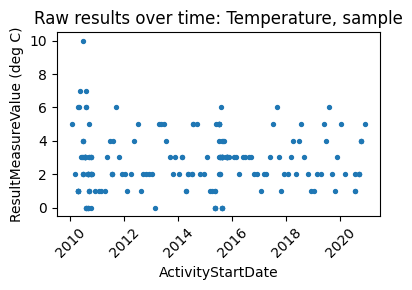

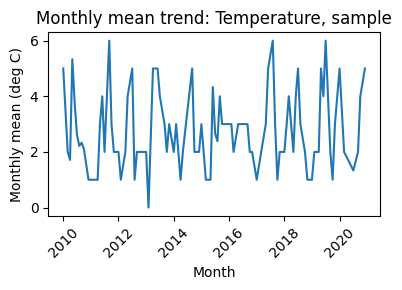

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


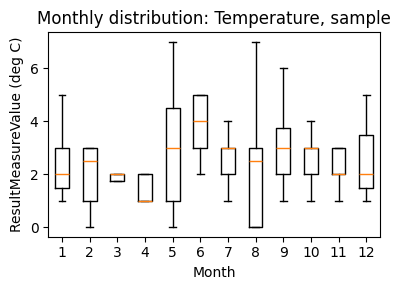

Plotting characteristic: Chloride | unit: mg/L


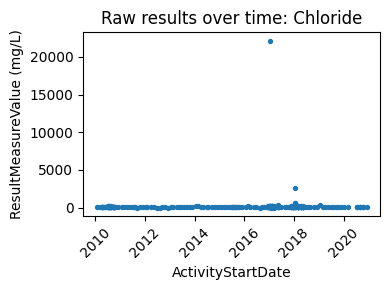

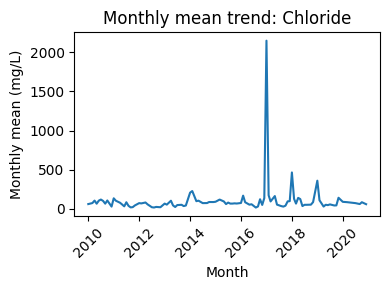

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


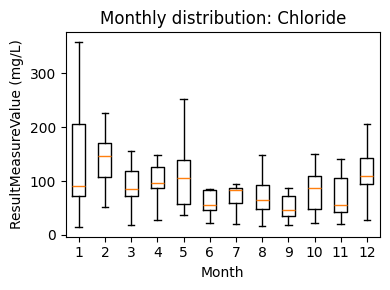

Plotting characteristic: Specific conductance | unit: uS/cm


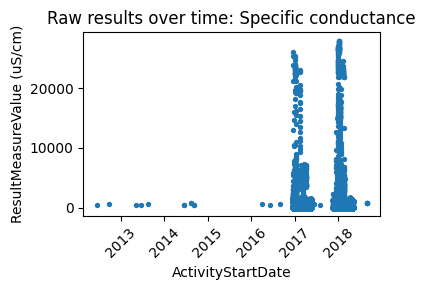

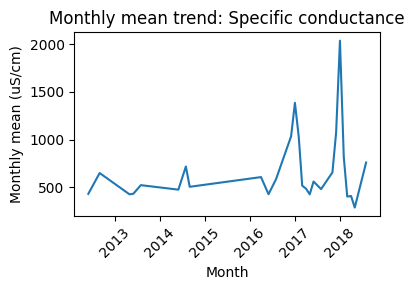

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


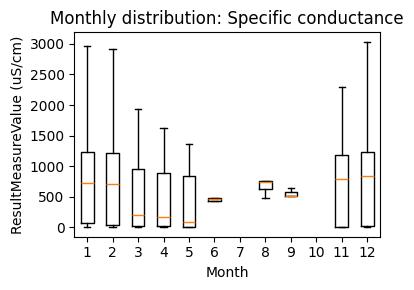

Plotting characteristic: Flow | unit: cfs


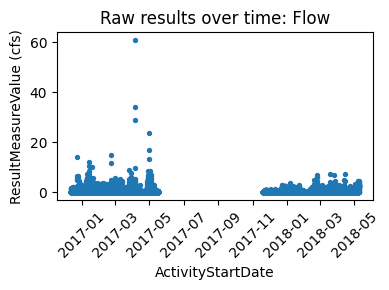

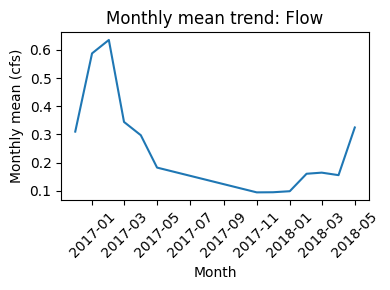

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


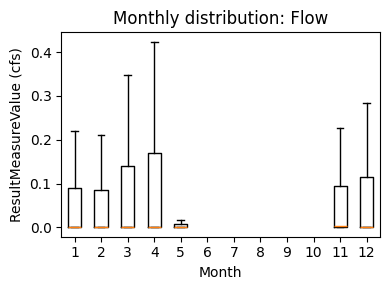

Plotting characteristic: Organic carbon | unit: mg/L


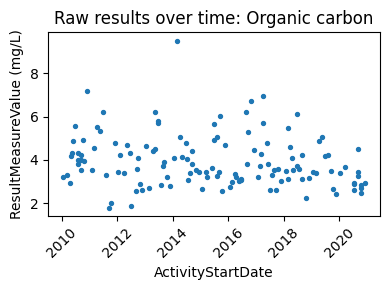

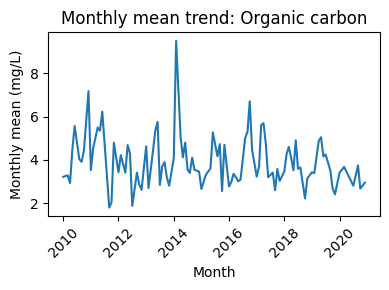

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


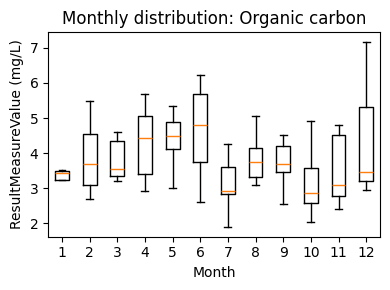

Plotting characteristic: pH | unit: None


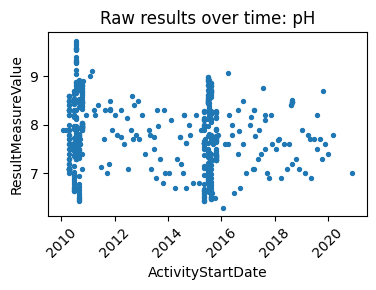

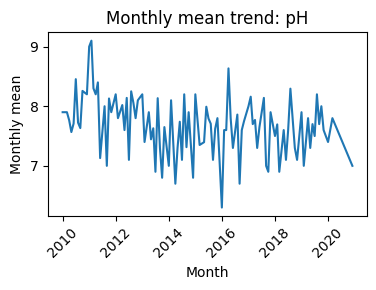

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


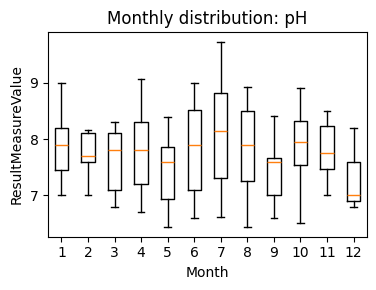

Plotting characteristic: Alkalinity, total | unit: mg/L


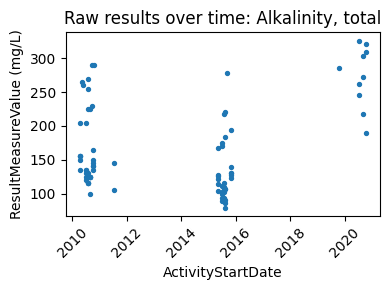

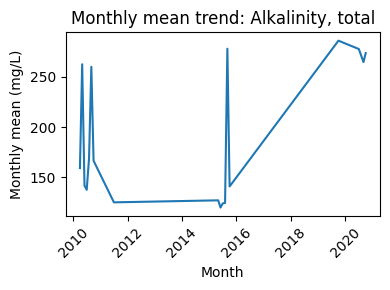

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


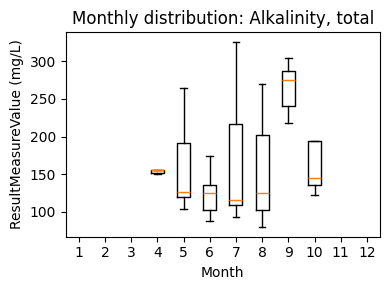

Plotting characteristic: Depth, Secchi disk depth | unit: in


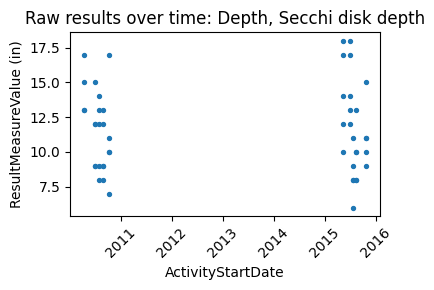

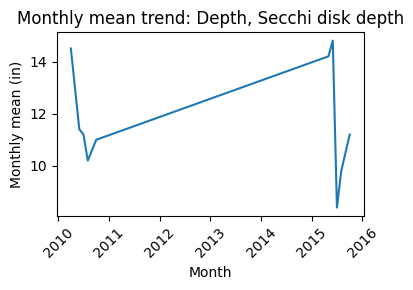

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


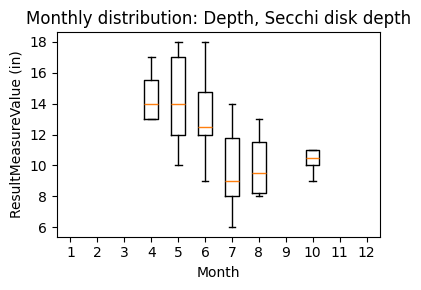

Skipping 'Oxygen' (no rows after filtering).
Plotting characteristic: Total dissolved solids | unit: mg/L


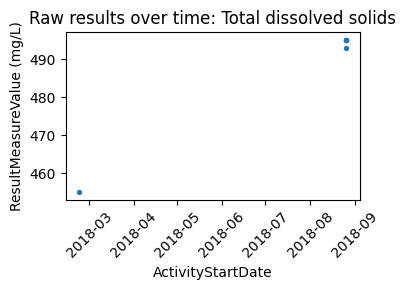

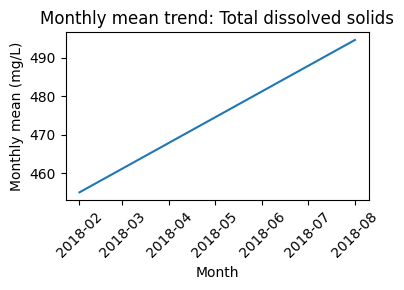

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


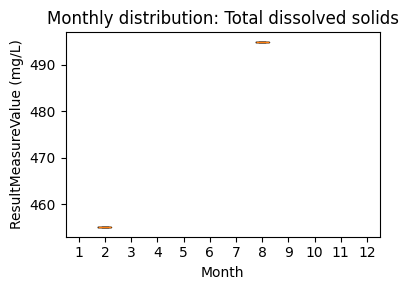

Plotting characteristic: Nitrogen | unit: ug/L


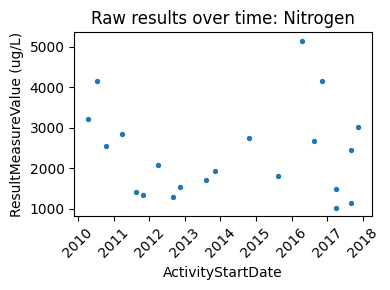

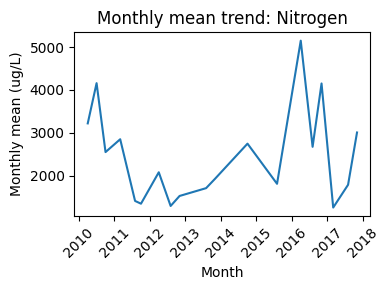

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


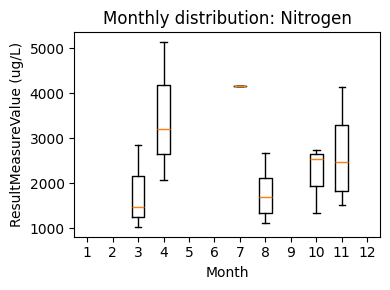

Plotting characteristic: Phosphorus | unit: mg/L


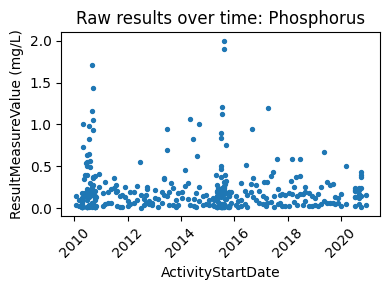

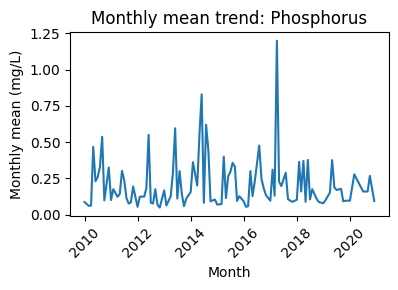

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


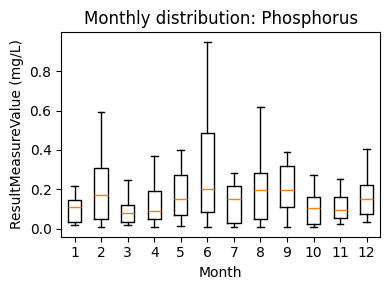

Plotting characteristic: Chlorophyll a | unit: ug/L


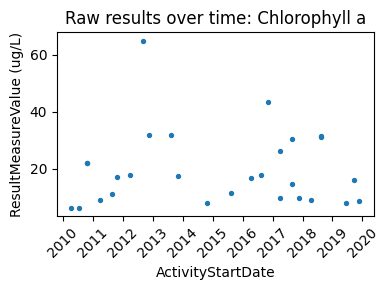

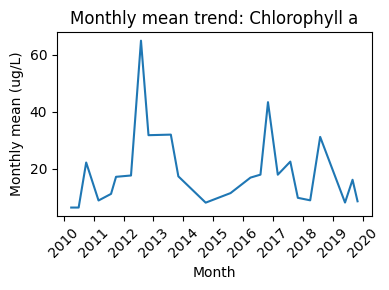

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


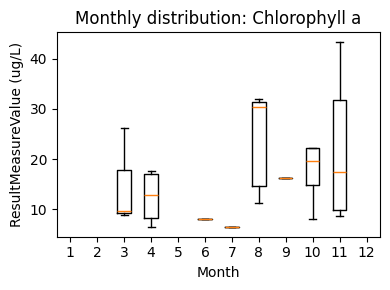

Skipping 'Reservoir volume' (no rows after filtering).
Plotting characteristic: Total suspended solids | unit: mg/L


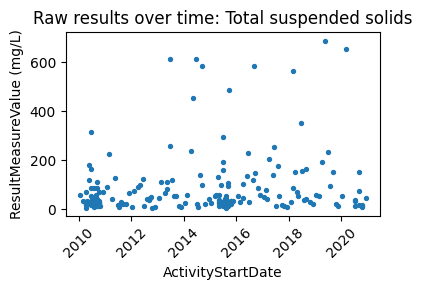

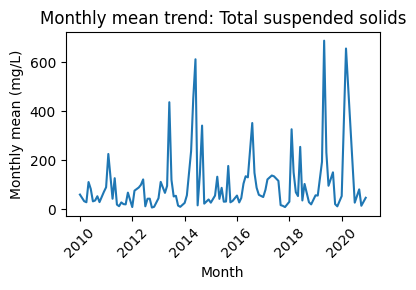

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


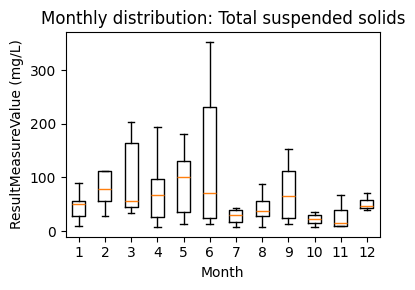

Plotting characteristic: Escherichia coli | unit: #/100mL


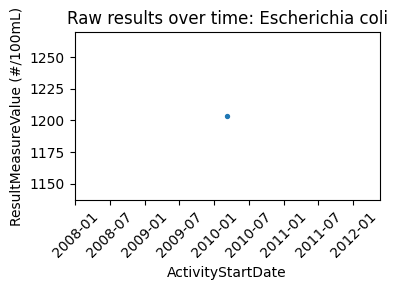

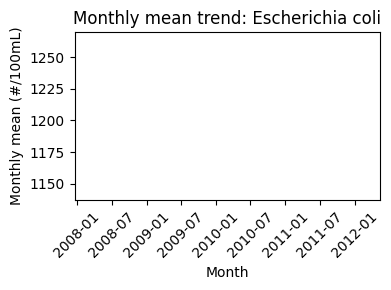

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


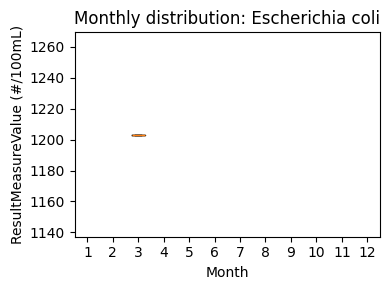

Skipping 'Hardness, magnesium' (no rows after filtering).
Plotting characteristic: Orthophosphate | unit: mg/L


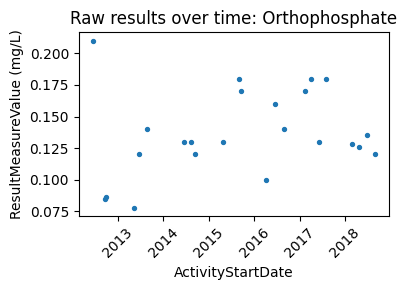

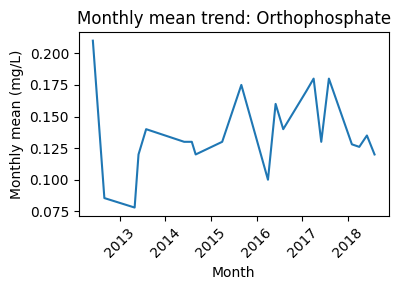

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


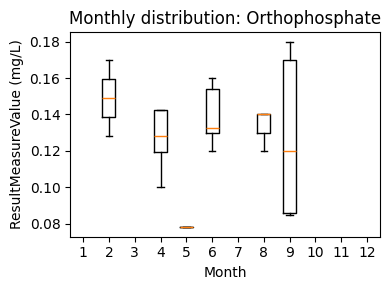

Skipping 'Precipitation' (no rows after filtering).
Plotting characteristic: Sulfate | unit: mg/L


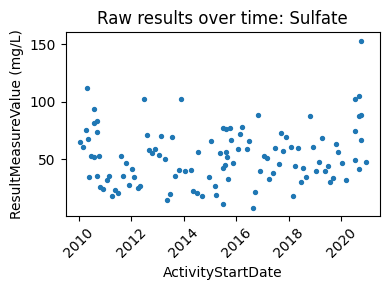

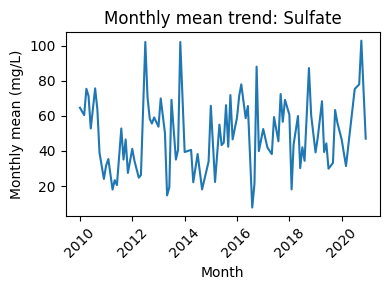

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


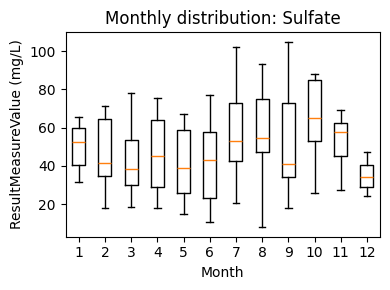

Plotting characteristic: Inorganic nitrogen (nitrate and nitrite) ***retired***use Nitrate + Nitrite | unit: mg/L


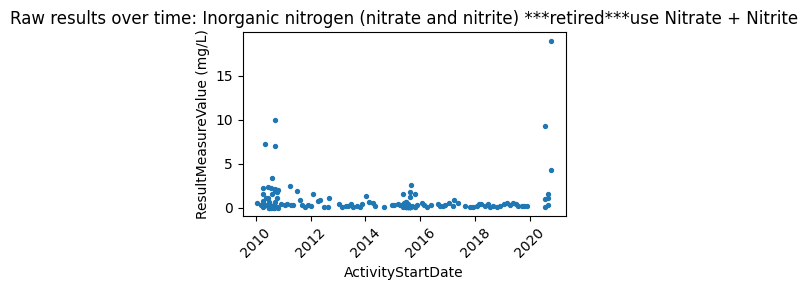

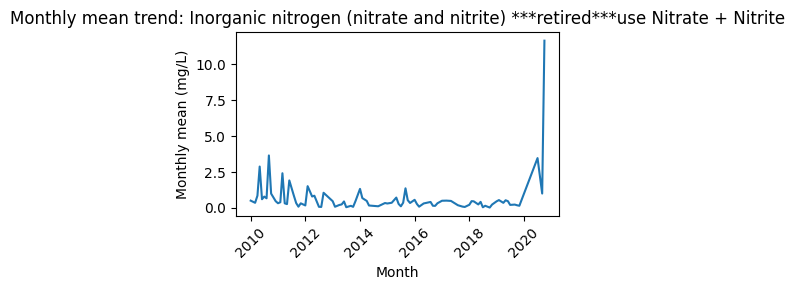

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


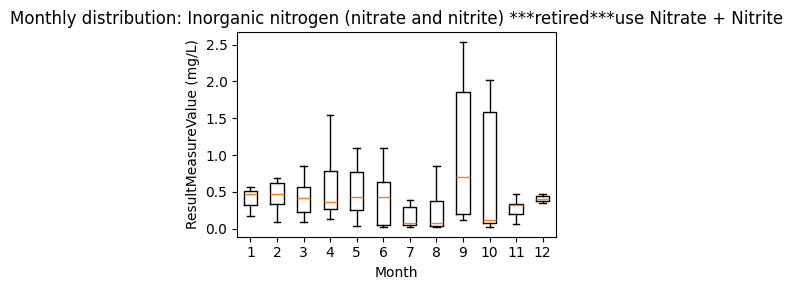

Plotting characteristic: Pheophytin a | unit: ug/L


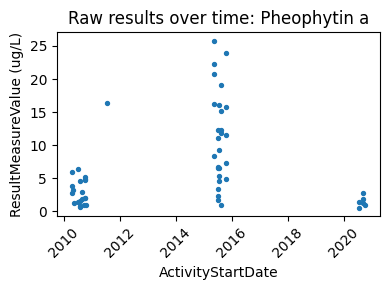

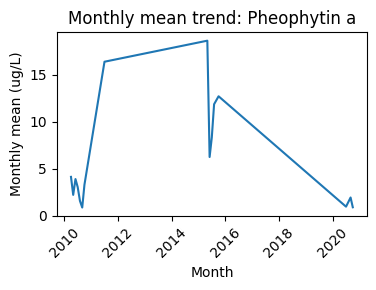

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


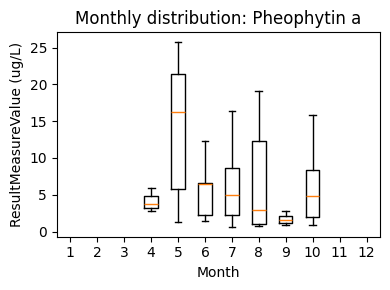

Plotting characteristic: Nitrate | unit: mg/L


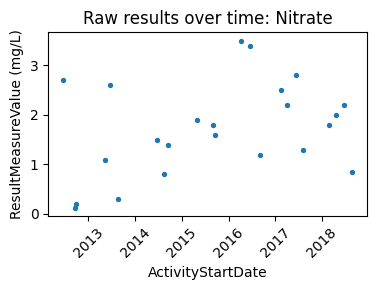

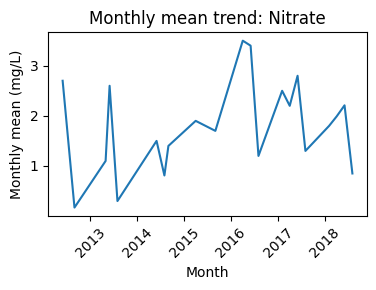

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


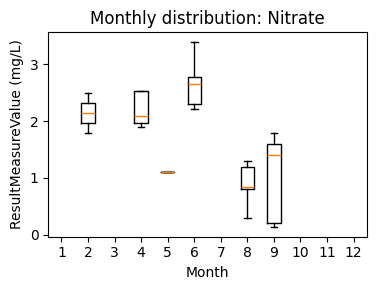

Plotting characteristic: Depth | unit: ft


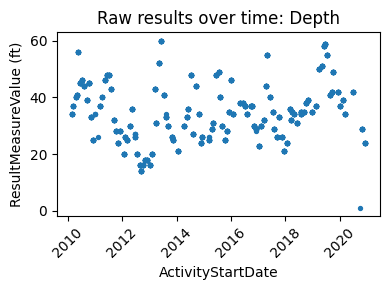

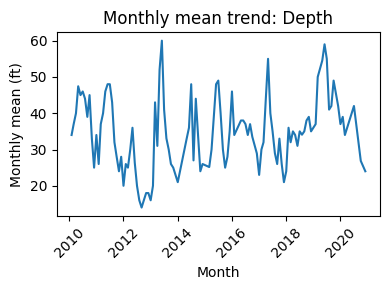

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


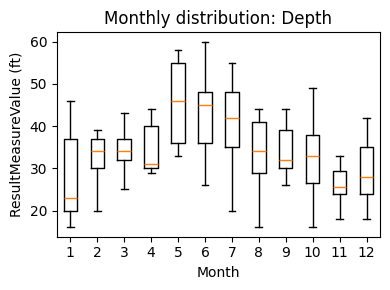

Plotting characteristic: Total volatile solids | unit: %


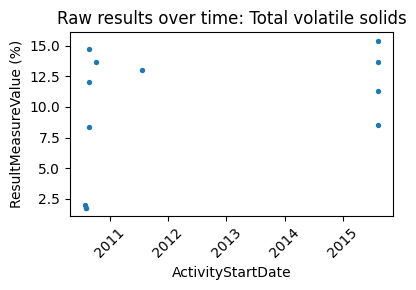

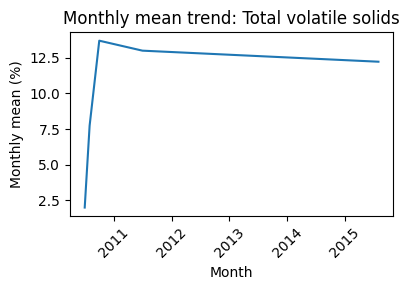

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


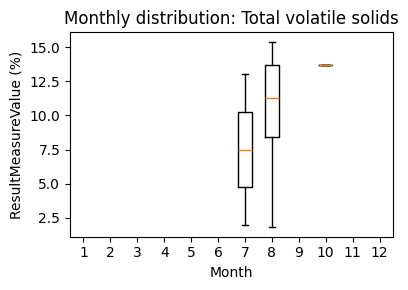

Plotting characteristic: Iron | unit: ug/L


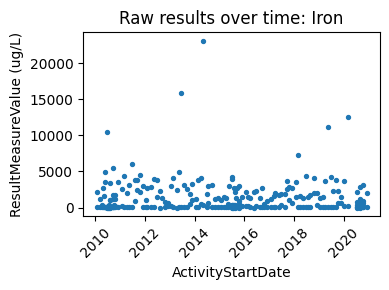

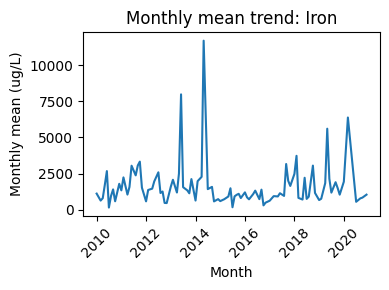

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


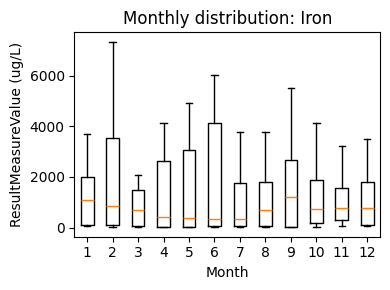

Plotting characteristic: Ammonia-nitrogen | unit: mg/L


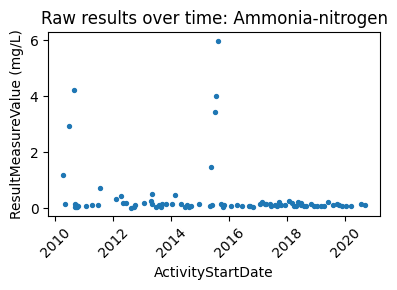

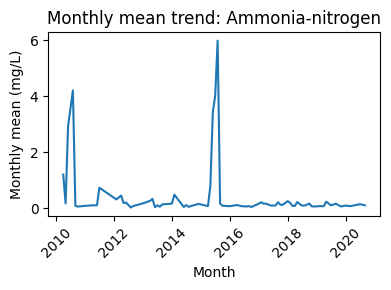

C:\Users\kcui2\AppData\Local\Temp\ipykernel_50804\2860930389.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=months, showfliers=showfliers)


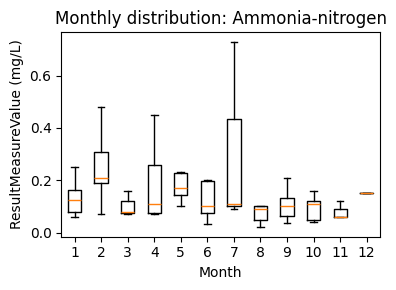

Skipping 'Nitrite' (no rows after filtering).


In [7]:
chars = [
    "Temperature, sample",
    "Chloride",
    "Specific conductance",
    "Flow",
    "Organic carbon",
    "pH",
    "Alkalinity, total",
    "Depth, Secchi disk depth",
    "Oxygen",
    "Total dissolved solids",
    "Nitrogen",
    "Phosphorus",
    "Chlorophyll a",
    "Reservoir volume",
    "Total suspended solids",
    "Escherichia coli",
    "Hardness, magnesium",
    "Orthophosphate",
    "Precipitation",
    "Sulfate",
    "Inorganic nitrogen (nitrate and nitrite) ***retired***use Nitrate + Nitrite",
    "Pheophytin a",
    "Nitrate",
    "Depth",
    "Total volatile solids",
    "Iron",
    "Ammonia-nitrogen",
    "Nitrite"
]
plot_wqp_characteristic_trends(df_target, chars)


In [8]:
import pandas as pd
import numpy as np

def classify_selected_characteristics(df):

    df["ActivityStartDate"] = pd.to_datetime(df["ActivityStartDate"])
    df = df[df["CharacteristicName"].isin(chars)]

    results = []

    for char, g in df.groupby("CharacteristicName"):

        g = g.sort_values("ActivityStartDate")
        g["month"] = g["ActivityStartDate"].dt.to_period("M")

        counts = g.groupby("month").size()

        start = counts.index.min()
        end = counts.index.max()

        full_range = pd.period_range(start=start, end=end, freq="M")
        counts = counts.reindex(full_range, fill_value=0)

        months_with_data = (counts > 0).sum()
        total_months = len(counts)
        coverage = months_with_data / total_months

        # longest gap
        longest_gap = 0
        gap = 0
        for v in counts:
            if v == 0:
                gap += 1
                longest_gap = max(longest_gap, gap)
            else:
                gap = 0

        obs = len(g)

        if obs == 0:
            label = "Bad (no data)"
        elif coverage > 0.75 and longest_gap <= 2:
            label = "Good"
        elif coverage > 0.40:
            label = "Okay"
        else:
            label = "Bad"

        results.append({
            "Characteristic": char,
            "Observations": obs,
            "Coverage": round(coverage,2),
            "LongestGapMonths": longest_gap,
            "Label": label
        })

    return pd.DataFrame(results)


summary = classify_selected_characteristics(df)
summary.sort_values("Label")

,Characteristic,Observations,Coverage,LongestGapMonths,Label
0,"Alkalinity, total",82,0.14,47,Bad
19,Total dissolved solids,6,0.29,5,Bad
14,Pheophytin a,95,0.29,22,Bad
13,Orthophosphate,23,0.28,9,Bad
21,Total volatile solids,12,0.08,48,Bad
10,Nitrate,23,0.28,9,Bad
7,Flow,30628,0.15,78,Bad
11,Nitrogen,21,0.21,10,Bad
5,"Depth, Secchi disk depth",49,0.15,54,Bad
3,Chlorophyll a,31,0.22,10,Bad


In [9]:
import os

os.makedirs("../../data/raw", exist_ok=True)

df_target.to_csv("../../data/raw/st_louis.csv", index=False)

print("saved st_louis.csv")

saved st_louis.csv
